In [1]:
import numpy as np
import scipy.sparse.linalg
import matplotlib.pyplot as plt
import typing
import cv2
import torch

from util.solver import assemble_poisson_problem
from util.solver import assemble_biharmonic_problem
from util.preparation import get_laplacian_map
from util.misc import plt_subplot

np.set_printoptions(linewidth=200) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

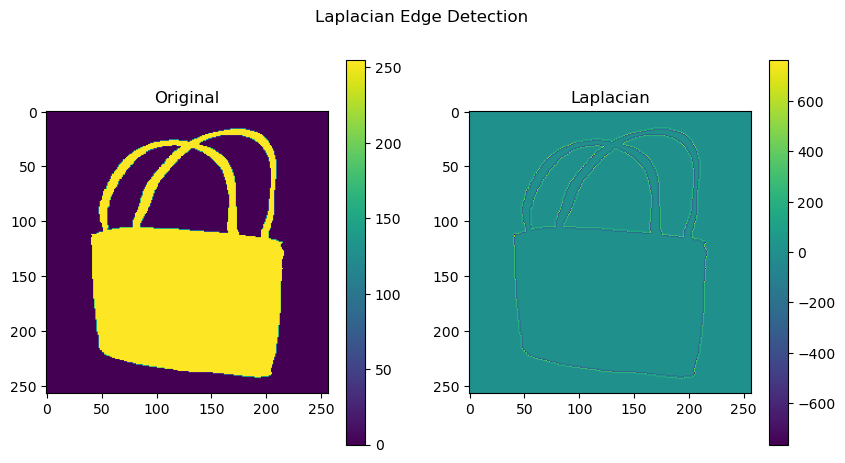

In [2]:
img = cv2.imread("var/testcase/bmp/257/bag.bmp", cv2.IMREAD_GRAYSCALE)  # ensures 2D grayscale
img = img.astype(np.float32)  # convert to float32

lap_map = get_laplacian_map(img)
plt_subplot({
    "Original": img,
    "Laplacian": lap_map
}, suptitle="Laplacian Edge Detection", unit_size=5)

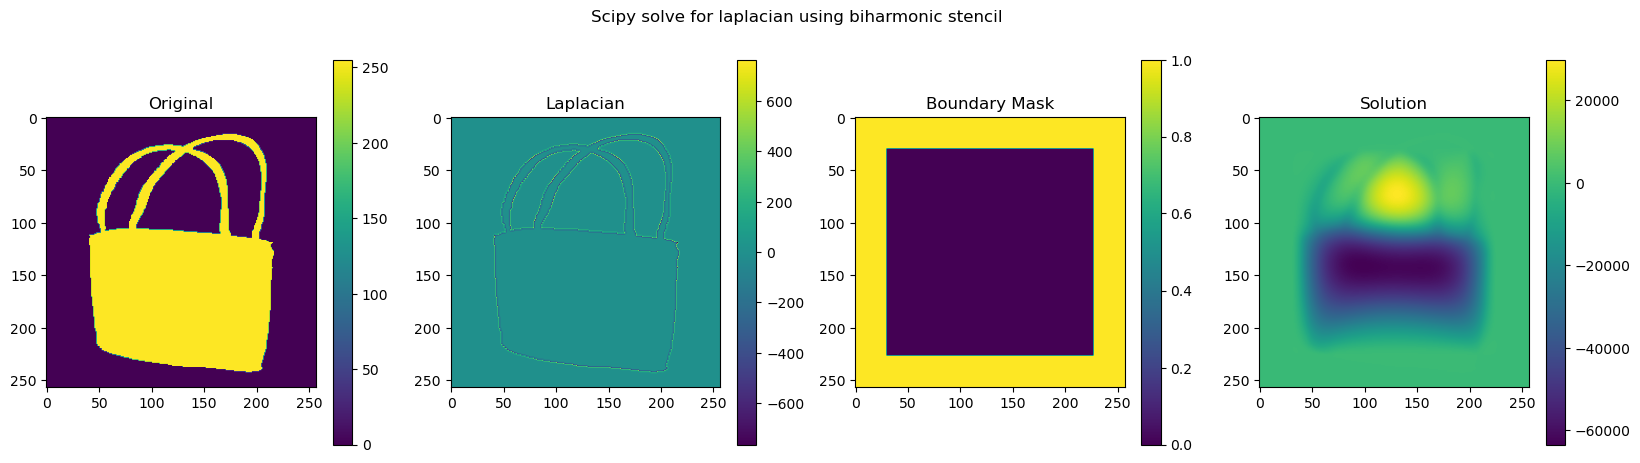

In [3]:
from util.preparation import square_region_with_source
# a version from util/solver.py but with assemble_biharmonic_problem
def scipy_solve(bc_value: np.ndarray,
                bc_mask: np.ndarray,
                f: typing.Optional[np.ndarray]):
    A, rhs = assemble_biharmonic_problem(bc_value, bc_mask, f)
    X = scipy.sparse.linalg.spsolve(A, rhs)
    X.resize(bc_mask.shape)
    return X.astype(np.float32)

bc_value, bc_mask, f = square_region_with_source(source=img, laplacian=lap_map, device=device)

# convert it back to numpy tensor just for testing, so that scipy legacy solver can be used
if isinstance(bc_value, torch.Tensor):
    bc_value = bc_value.squeeze().detach().cpu().numpy()
if isinstance(bc_mask, torch.Tensor):
    bc_mask = bc_mask.squeeze().detach().cpu().numpy()
if isinstance(f, torch.Tensor):
    f = f.detach().squeeze().cpu().numpy()

solution = scipy_solve(bc_value.astype(np.float32), bc_mask.astype(np.float32), f.astype(np.float32))

plt_subplot({
    "Original": img,
    "Laplacian": lap_map,
    "Boundary Mask": bc_mask,
    "Solution": solution
}, suptitle="Scipy solve for laplacian using biharmonic stencil", unit_size=5)

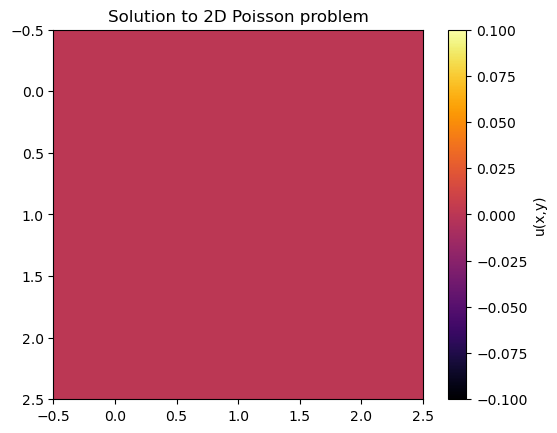

In [ ]:
N = 3  # grid size
bc_mask = np.zeros((N, N), dtype=np.uint8)
bc_value = np.zeros((N, N), dtype=np.float32)
f = np.zeros((N, N), dtype=np.float32)

# set boundary condition (u = 1 at top edge, 0 elsewhere)
# bc_mask[0, :] = 1
# bc_value[0, :] = 1.0

# assemble system
A, rhs = assemble_poisson_problem(bc_value, bc_mask, f)

# solve linear system
u = scipy.sparse.linalg.spsolve(A, rhs)

# reshape back to grid
u_grid = u.reshape(N, N)

# visualize
plt.imshow(u_grid, cmap="inferno")
plt.colorbar(label="u(x,y)")
plt.title("Solution to 2D Poisson problem")
plt.show()

In [2]:
np.set_printoptions(linewidth=200) 
print("Right-hand side (rhs):")
print(rhs.reshape(N, N))

print(f"\nSparse matrix A (dense view) {A.shape}:")
dense_A = A.toarray()
for row in dense_A:
    print(row)


Right-hand side (rhs):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Sparse matrix A (dense view) (9, 9):
[-4.  1.  0.  1.  0.  0.  0.  0.  0.]
[ 1. -4.  1.  0.  1.  0.  0.  0.  0.]
[ 0.  1. -4.  0.  0.  1.  0.  0.  0.]
[ 1.  0.  0. -4.  1.  0.  1.  0.  0.]
[ 0.  1.  0.  1. -4.  1.  0.  1.  0.]
[ 0.  0.  1.  0.  1. -4.  0.  0.  1.]
[ 0.  0.  0.  1.  0.  0. -4.  1.  0.]
[ 0.  0.  0.  0.  1.  0.  1. -4.  1.]
[ 0.  0.  0.  0.  0.  1.  0.  1. -4.]


In [ ]:
N2 = 5  # grid size
bc_mask = np.zeros((N2, N2), dtype=np.uint8)
bc_value = np.zeros((N2, N2), dtype=np.float32)
f = np.zeros((N2, N2), dtype=np.float32)
A, rhs = assemble_biharmonic_problem(bc_value, bc_mask, f)
print("Right-hand side (rhs):")
print(rhs.reshape(N2, N2))

print(f"\nSparse matrix A (dense view) {A.shape}:")
dense_A = A.toarray()
for row in dense_A:
    print(row)

[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 23, 24, 24, 24, 24, 24, 24]
[2, 10, 1, 5, 6, 0, 3, 11, 0, 2, 6, 5, 7, 1, 0, 4, 12, 1, 3, 7, 6, 8, 2, 1, 13, 2, 4, 8, 7, 9, 3, 2, 14, 3, 9, 8, 4, 7, 15, 6, 0, 10, 1, 11, 5, 8, 16, 5, 7, 1, 11, 0, 2, 